In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv("/content/pipe_thickness_loss_dataset.csv")
data.head()

,Pipe_ID,Pipe_Size_mm,Diameter_mm,Thickness_mm,Material,Strength_MPa,Grade,Max_Pressure_Bar,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Temperature_C,Condition
0,1,747,565,24.25,Copper,269.38,B,142.90,16.20,1.93,8.58,22,22.3,Normal
1,2,412,1407,14.04,Cast Iron,518.66,B,53.72,7.53,6.51,9.33,17,60.6,Critical
2,3,320,1253,4.21,Aluminum,275.55,A,197.64,12.90,0.30,2.42,7,-1.1,Normal
3,4,1103,1639,25.03,Aluminum,380.29,C,186.96,14.84,7.49,4.74,6,79.1,Critical
4,5,486,1822,7.60,Copper,279.03,D,91.39,4.69,7.62,1.21,22,77.2,Critical


**Observation 1**: The Pipe_ID column is of little use. Therefore, it needs to be dropped.

In [3]:
data.drop("Pipe_ID",axis=1,inplace=True)

In [4]:
data.shape

(1000, 13)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pipe_Size_mm              1000 non-null   int64  
 1   Diameter_mm               1000 non-null   int64  
 2   Thickness_mm              1000 non-null   float64
 3   Material                  1000 non-null   object 
 4   Strength_MPa              1000 non-null   float64
 5   Grade                     1000 non-null   object 
 6   Max_Pressure_Bar          1000 non-null   float64
 7   Corrosion_Impact_Percent  1000 non-null   float64
 8   Thickness_Loss_mm         1000 non-null   float64
 9   Material_Loss_Percent     1000 non-null   float64
 10  Time_Years                1000 non-null   int64  
 11  Temperature_C             1000 non-null   float64
 12  Condition                 1000 non-null   object 
dtypes: float64(7), int64(3), object(3)
memory usage: 101.7+ KB


In [6]:
data.describe()

,Pipe_Size_mm,Diameter_mm,Thickness_mm,Strength_MPa,Max_Pressure_Bar,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Temperature_C
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,790.561000,1013.072000,16.516870,497.157060,104.848160,10.085310,4.961850,4.922650,12.973000,38.952600
std,418.868186,540.195932,7.805433,168.913032,56.596569,5.931709,2.851882,2.882145,7.069105,46.281236
min,53.000000,104.000000,3.060000,201.160000,10.480000,0.010000,0.000000,0.000000,1.000000,-39.800000
25%,426.000000,570.000000,9.762500,350.765000,54.362500,4.960000,2.590000,2.447500,7.000000,-1.700000
50%,785.000000,987.500000,16.415000,495.175000,101.315000,10.195000,4.740000,4.790000,13.000000,36.350000
75%,1149.000000,1452.500000,23.430000,640.335000,155.947500,15.407500,7.410000,7.452500,19.000000,80.825000
max,1499.000000,1999.000000,29.980000,799.520000,199.910000,19.980000,10.000000,9.990000,24.000000,120.000000


In [7]:
data.isnull().sum()

,0
Pipe_Size_mm,0
Diameter_mm,0
Thickness_mm,0
Material,0
Strength_MPa,0
Grade,0
Max_Pressure_Bar,0
Corrosion_Impact_Percent,0
Thickness_Loss_mm,0
Material_Loss_Percent,0


**Observation 2**: There are no missing values in our dataset.

In [8]:
print(data.shape)


(1000, 13)


In [9]:
data.drop_duplicates(inplace=True)
data.shape

(1000, 13)

**Observation 3**: There are no duplicate rows in our dataset.

In [10]:
data.head(2)

,Pipe_Size_mm,Diameter_mm,Thickness_mm,Material,Strength_MPa,Grade,Max_Pressure_Bar,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Temperature_C,Condition
0,747,565,24.25,Copper,269.38,B,142.90,16.20,1.93,8.58,22,22.3,Normal
1,412,1407,14.04,Cast Iron,518.66,B,53.72,7.53,6.51,9.33,17,60.6,Critical


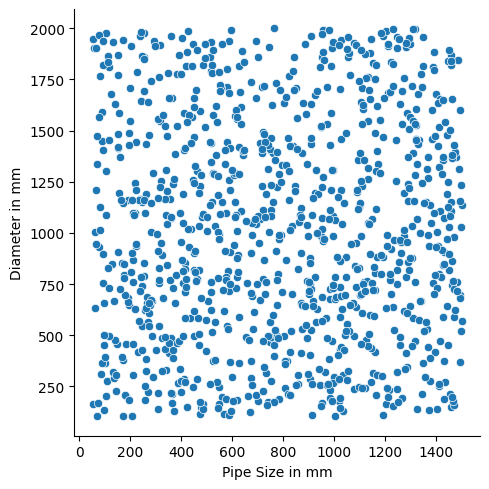

In [11]:
sns.relplot(x="Pipe_Size_mm",y="Diameter_mm",data=data,kind="scatter")
plt.ylabel("Diameter in mm")
plt.xlabel("Pipe Size in mm")
plt.show()

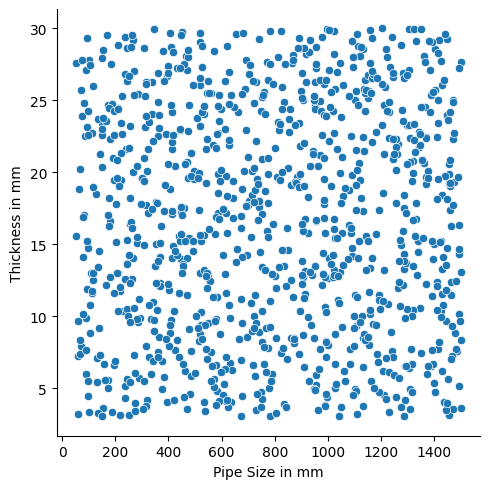

In [12]:
sns.relplot(x="Pipe_Size_mm",y="Thickness_mm",data=data,kind="scatter")
plt.ylabel("Thickness in mm")
plt.xlabel("Pipe Size in mm")
plt.show()

In [13]:
data.head(1)

,Pipe_Size_mm,Diameter_mm,Thickness_mm,Material,Strength_MPa,Grade,Max_Pressure_Bar,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Temperature_C,Condition
0,747,565,24.25,Copper,269.38,B,142.9,16.2,1.93,8.58,22,22.3,Normal


In [14]:
data["Material"].unique()

array(['Copper', 'Cast Iron', 'Aluminum', 'Steel', 'PVC'], dtype=object)

In [15]:
data = pd.get_dummies(data, columns=["Material"], drop_first=True)

In [16]:
print(data.isnull().sum())

Pipe_Size_mm                0
Diameter_mm                 0
Thickness_mm                0
Strength_MPa                0
Grade                       0
Max_Pressure_Bar            0
Corrosion_Impact_Percent    0
Thickness_Loss_mm           0
Material_Loss_Percent       0
Time_Years                  0
Temperature_C               0
Condition                   0
Material_Cast Iron          0
Material_Copper             0
Material_PVC                0
Material_Steel              0
dtype: int64


In [17]:
data = data.astype({col: 'int' for col in data.columns if col.startswith("Material_")})

In [18]:
data.sample(7)

,Pipe_Size_mm,Diameter_mm,Thickness_mm,Strength_MPa,Grade,Max_Pressure_Bar,Corrosion_Impact_Percent,Thickness_Loss_mm,Material_Loss_Percent,Time_Years,Temperature_C,Condition,Material_Cast Iron,Material_Copper,Material_PVC,Material_Steel
47,313,754,23.11,495.21,A,190.13,4.67,6.01,5,16,-25.0,Critical,0,1,0,0
13,130,846,7.11,650.97,E,28.20,16.07,7.32,1,1,96.1,Critical,0,0,1,0
101,149,456,22.98,334.08,C,106.95,11.29,6.26,0,3,-1.7,Critical,1,0,0,0
572,1136,505,8.78,583.56,D,43.47,18.57,4.51,9,4,17.2,Moderate,1,0,0,0
594,243,1980,13.60,302.08,B,81.24,18.46,0.04,4,2,9.3,Normal,0,1,0,0
988,1275,1195,3.71,504.23,D,158.22,3.16,4.18,3,22,89.4,Moderate,0,0,0,1
30,150,1772,22.61,686.73,B,88.28,3.81,0.86,1,7,69.5,Normal,0,0,0,0


In [19]:
data["Grade"].unique()

array(['B', 'A', 'C', 'D', 'E'], dtype=object)

In [20]:
Grade_dict = {"A":"4","B":"3","C":"2","D":"1","E":"0"}
data["Grade"] = data["Grade"].map(Grade_dict)

In [21]:
data["Grade"] = data["Grade"].astype(int)
print(data["Grade"].dtype)

int64


In [22]:
data["Condition"].unique()

array(['Normal', 'Critical', 'Moderate'], dtype=object)

In [23]:
Dict_condition = {"Normal":"2", "Critical":"0","Moderate":"1"}
data["Condition"] = data["Condition"].map(Dict_condition)

In [24]:
data["Condition"] = data["Condition"].astype(int)
print(data["Condition"].dtype)

int64


In [25]:
data.dtypes

,0
Pipe_Size_mm,int64
Diameter_mm,int64
Thickness_mm,float64
Strength_MPa,float64
Grade,int64
Max_Pressure_Bar,float64
Corrosion_Impact_Percent,float64
Thickness_Loss_mm,float64
Material_Loss_Percent,int64
Time_Years,int64


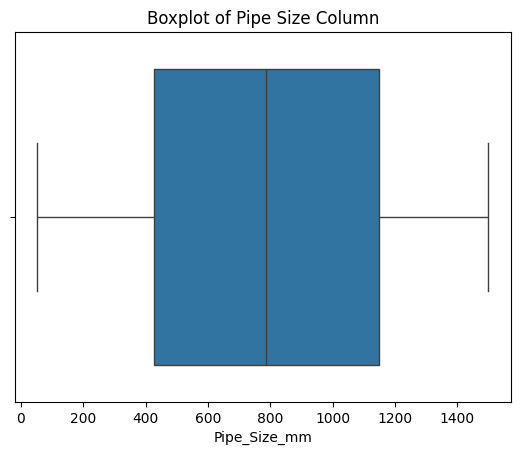

In [26]:
#Checking for outliers now in each column
sns.boxplot(x="Pipe_Size_mm",data=data)
plt.title("Boxplot of Pipe Size Column")
plt.show()

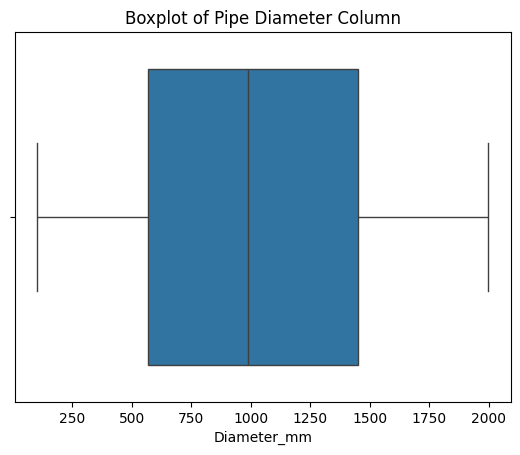

In [27]:
sns.boxplot(x="Diameter_mm",data=data)
plt.title("Boxplot of Pipe Diameter Column")
plt.show()

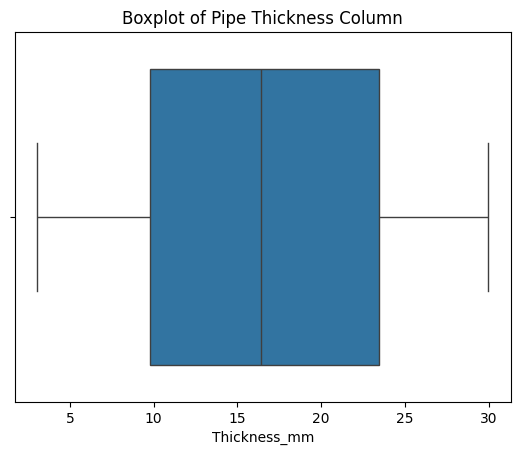

In [28]:
sns.boxplot(x="Thickness_mm",data=data)
plt.title("Boxplot of Pipe Thickness Column")
plt.show()

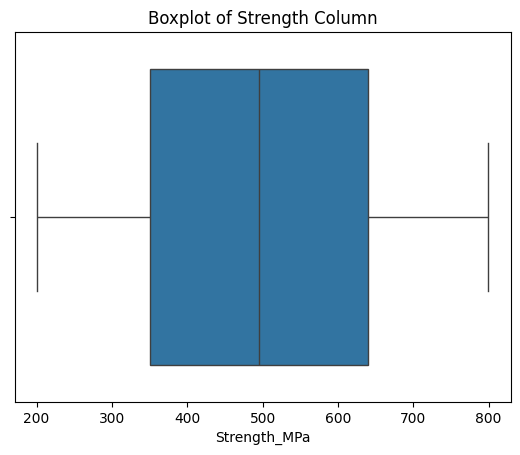

In [29]:
sns.boxplot(x="Strength_MPa",data=data)
plt.title("Boxplot of Strength Column")
plt.show()

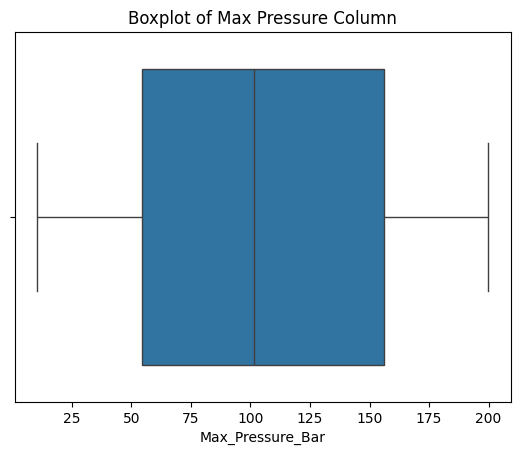

In [30]:
sns.boxplot(x="Max_Pressure_Bar",data=data)
plt.title("Boxplot of Max Pressure Column")
plt.show()

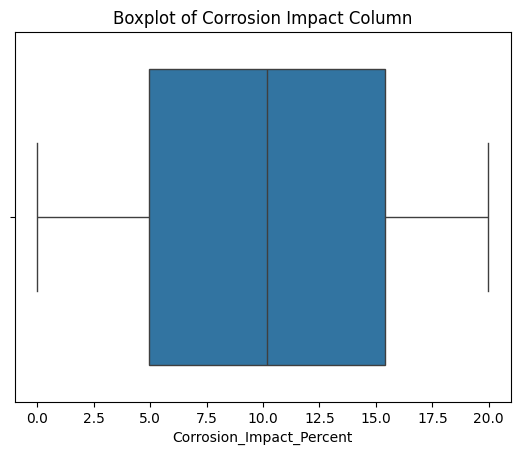

In [31]:
sns.boxplot(x="Corrosion_Impact_Percent",data=data)
plt.title("Boxplot of Corrosion Impact Column")
plt.show()

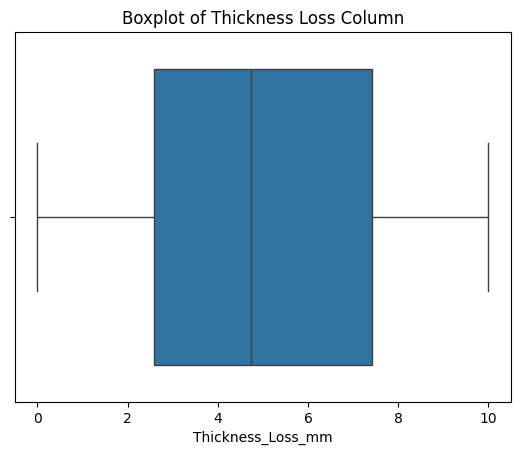

In [32]:
sns.boxplot(x="Thickness_Loss_mm",data=data)
plt.title("Boxplot of Thickness Loss Column")
plt.show()

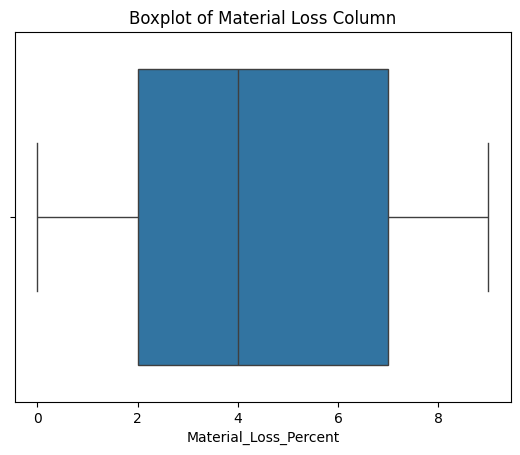

In [33]:
sns.boxplot(x="Material_Loss_Percent",data=data)
plt.title("Boxplot of Material Loss Column")
plt.show()

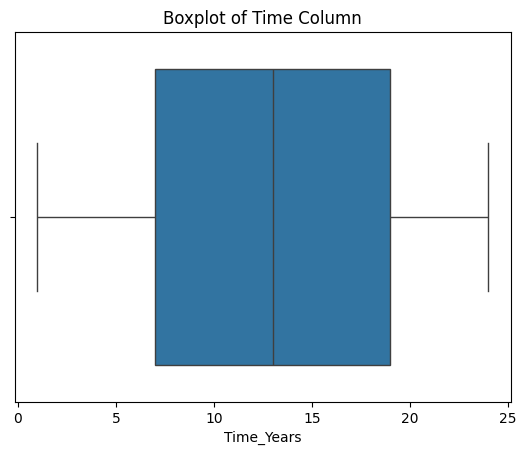

In [34]:
sns.boxplot(x="Time_Years",data=data)
plt.title("Boxplot of Time Column")
plt.show()

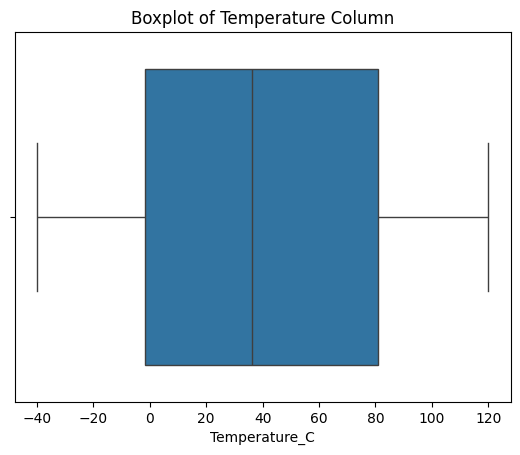

In [35]:
sns.boxplot(x="Temperature_C",data=data)
plt.title("Boxplot of Temperature Column")
plt.show()

**Observation 4**: There are no outliers in any of the numerical columns.

In [52]:
X = data.drop("Condition",axis=1)
Y = data["Condition"]

In [53]:
from sklearn.preprocessing import StandardScaler
SS = StandardScaler()
X_ss = pd.DataFrame(SS.fit_transform(X),columns=X.columns)


In [54]:
X_ss.shape

(1000, 15)

In [55]:
from imblearn.over_sampling import RandomOverSampler
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_resampled, Y_resampled = ros.fit_resample(X_ss, Y)

# Check class distribution after oversampling
from collections import Counter
print(Counter(Y_resampled))


Counter({2: 477, 0: 477, 1: 477})


In [57]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_resampled,Y_resampled,test_size=0.2,random_state=42)

In [58]:
Y_resampled.shape

(1431,)

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

lr = LogisticRegression(multi_class="multinomial",class_weight="balanced",random_state=42)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
y_train_pred = lr.predict(X_train)
print(classification_report(y_test, y_pred))
print("Test Accuracy: ", accuracy_score(y_test, y_pred))
print("Train Accuracy: ",accuracy_score(y_train,y_train_pred))


              precision    recall  f1-score   support

           0       1.00      0.97      0.98        92
           1       0.94      0.91      0.92       101
           2       0.91      0.97      0.94        94

    accuracy                           0.95       287
   macro avg       0.95      0.95      0.95       287
weighted avg       0.95      0.95      0.95       287

Test Accuracy:  0.9477351916376306
Train Accuracy:  0.9886363636363636


In [65]:
Y_resampled.value_counts(ascending=False)

,count
Condition,
2,477
0,477
1,477
